# Module 7 — Feature Adoption *(recap)*

Part of the Product Analytics Playbook. Program and progress: [CURRICULUM.md](CURRICULUM.md).

## Why you're here: what this module is for

Feature adoption is covered in the Product Analytics Case Study. This module is a short recap: the two measures (adoption and usage share), what the Case Study's notebook `04_Feature_Adoption_and_Segmentation.ipynb` showed (with its printed numbers and link), and the same comparison on this playbook's store data.

## From the curriculum

> ## <u>Module 7 — Feature Adoption</u> *(recap)*
>
> **Covered in:** Product Analytics Case Study,
> [`04_Feature_Adoption_and_Segmentation.ipynb`](https://github.com/omri-sabag83/Product-Analytics-Case-Study/blob/main/04_Feature_Adoption_and_Segmentation.ipynb),
> "Adoption" and "Does the mix of features used relate to outcome, independent
> of volume?"
>
> **Recap:** adoption (share of users who ever use it) vs. usage share (share of
> activity), and mix vs. volume (how activity splits across features vs. how much
> activity there is).
>
> **Compact recompute:** adoption vs. usage share on the running dataset's
> nearest "feature" dimension.

## Recap

**Definitions:**
- **Adoption** of a feature = the share of users who used it at least once.
- **Usage share** = the feature's share of all activity (all events or clicks).
- **Events per adopter** = the feature's activity ÷ the users who used it at least once.
- Adoption says *how many* people use a feature; usage share says *how much* of the activity it takes. Because one is a share of users and the other a share of activity, comparing them directly can mislead; events per adopter, against the overall events per user, is the fair comparison.
- **Mix vs. volume:** a user's *mix* is how their activity splits across features; their *volume* is how much activity they have in total. Heavy users tend to use more features, so before reading anything into the mix, compare users with similar volume.

### What the Case Study showed

[`04_Feature_Adoption_and_Segmentation.ipynb`](https://github.com/omri-sabag83/Product-Analytics-Case-Study/blob/main/04_Feature_Adoption_and_Segmentation.ipynb), sections "Adoption — what share of enrollments ever use each feature at all" and "Does the mix of features used relate to outcome, independent of volume?". An online-learning platform; a "feature" is a type of course page or tool, a "user" is an enrollment (one student on one course), and usage share is measured in clicks. Numbers quoted from its printed outputs (it printed fractions; they are shown as percentages here).

| feature | adoption | click share |
|---|---|---|
| homepage | 89.5% | 17.5% |
| resource | 84.7% | 2.8% |
| oucontent (course content) | 82.6% | 28.3% |
| forumng (forum) | 79.8% | 20.1% |
| quiz | 61.3% | 17.6% |
| oucollaborate (live sessions) | 33.4% | 0.3% |

For example, "resource" was used by 84.7% of enrollments but took only 2.8% of clicks.

**Mix vs. volume:** in a first draft, among the quarter of enrollments with the least activity, a higher share of quiz clicks went with passing the course (correlation 0.258). Once every enrollment was measured over the same first 14 days (so active students no longer had more time to rack up quizzes), the correlation became −0.035, and the notebook retracted the finding.

## Compact recompute: adoption vs. usage share on this store's data

**The nearest thing to features here:** a store log has no feature names; the closest thing is the event type (view, cart, remove_from_cart, purchase). These are actions, not features, so this is an analogy.

**Definitions:**
- **Adoption** = share of all 164,270 sampled users who did that action at least once, October 2019 to February 2020.
- **Usage share** = that action's share of all clean events.
- **Events per adopter** = that action's events ÷ the users who did it, over the five months; shown as the average and the median (the middle user), plus the share of the action's events made by its top 10% of users.
- A purchase event is one product line (Module 1), so a buyer's purchase events count items bought, not orders.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from common import connect, query, show, BLUE, ORANGE

con = connect()
ev = query(con, "SELECT user_id, event_type FROM events_clean")
n_users, n_events = ev["user_id"].nunique(), len(ev)
per_user = ev.groupby(["event_type", "user_id"]).size()

def top10_share(s):
    s = s.sort_values(ascending=False)
    return s.iloc[: max(1, int(len(s) * 0.10))].sum() / s.sum() * 100

g = pd.DataFrame({
    "events": per_user.groupby("event_type").sum(),
    "users": per_user.groupby("event_type").size(),
    "median": per_user.groupby("event_type").median(),
    "top10": per_user.groupby("event_type").apply(top10_share),
    "top10_avg": per_user.groupby("event_type").apply(lambda s: s.sort_values(ascending=False).iloc[: max(1, int(len(s) * 0.10))].mean()),
})
g["adoption"] = g["users"] / n_users * 100
g["usage_share"] = g["events"] / n_events * 100
g["per_adopter"] = g["events"] / g["users"]
g = g.sort_values("adoption", ascending=False)
print(f"users: {n_users:,}   clean events: {n_events:,}   overall events per user: {n_events:,} / {n_users:,} = {n_events / n_users:.2f}")
print()
show(pd.DataFrame({"event type": g.index,
                   "users": g["users"].map("{:,}".format).values,
                   "events": g["events"].map("{:,}".format).values,
                   "adoption %": g["adoption"].map("{:.2f}".format).values,
                   "usage share %": g["usage_share"].map("{:.2f}".format).values,
                   "events per adopter (avg)": g["per_adopter"].map("{:.2f}".format).values,
                   "events per adopter (median)": g["median"].map("{:.0f}".format).values,
                   "top 10% of adopters: share of events %": g["top10"].map("{:.2f}".format).values,
                   "events per adopter (top 10% avg)": g["top10_avg"].map("{:.2f}".format).values}))
all_users = ev.groupby("user_id").size()
print(f"\nall events, all users: top 10% of users make {top10_share(all_users):.2f}% of all events")
print(f"cart: {int(g.loc['cart', 'events']):,} cart events / {int(g.loc['cart', 'users']):,} cart users = {g.loc['cart', 'per_adopter']:.2f} per cart user")

users: 164,270   clean events: 1,920,835   overall events per user: 1,920,835 / 164,270 = 11.69

event type          users   events  adoption %  usage share %  events per adopter (avg)  events per adopter (median)  top 10% of adopters: share of events %  events per adopter (top 10% avg)
view              160,135  956,307       97.48          49.79                      5.97                            1                                   69.36                             41.42
cart               39,932  551,904       24.31          28.73                     13.82                            4                                   59.41                             82.11
remove_from_cart   18,231  286,893       11.10          14.94                     15.74                            5                                   59.45                             93.56
purchase           10,899  125,731        6.63           6.55                     11.54                            6                       

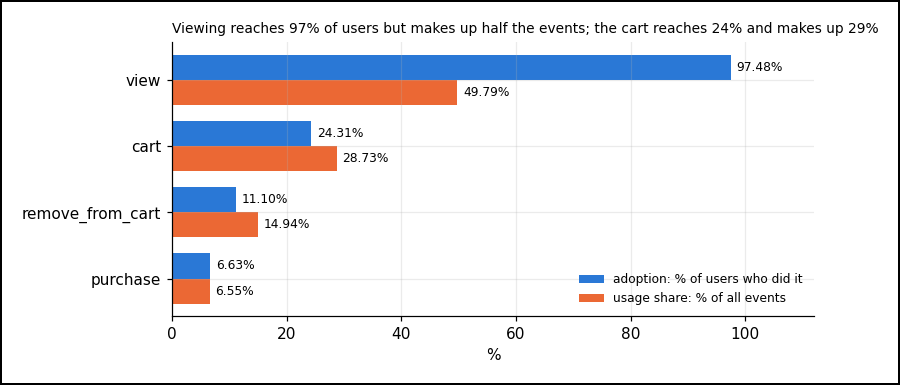

In [2]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
y = range(len(g))[::-1]
h = 0.38
ax.barh([v + h / 2 for v in y], g["adoption"], height=h, color=BLUE, label="adoption: % of users who did it")
ax.barh([v - h / 2 for v in y], g["usage_share"], height=h, color=ORANGE, label="usage share: % of all events")
for yy, (_, row) in zip(y, g.iterrows()):
    ax.text(row["adoption"] + 1, yy + h / 2, f"{row['adoption']:.2f}%", va="center", fontsize=8)
    ax.text(row["usage_share"] + 1, yy - h / 2, f"{row['usage_share']:.2f}%", va="center", fontsize=8)
ax.set_yticks(list(y), g.index)
ax.set_xlim(0, 112)
ax.set_xlabel("%")
ax.legend(frameon=False, loc="lower right", fontsize=8)
ax.set_title("Viewing reaches 97% of users but makes up half the events; the cart reaches 24% and makes up 29%", fontsize=9, loc="left")
plt.tight_layout(); plt.show()

**Observation:** viewing reaches 97.48% of users but makes up 49.79% of events; the average viewer has 5.97 views, below the overall 11.69 events per user. Views are spread thin: most users view a little.

**Observation:** the cart reaches 24.31% of users and makes up 28.73% of events. On average a cart user adds 13.82 times over the five months (551,904 ÷ 39,932), modestly above the overall 11.69. But the typical (median) cart user adds 4 times: the average is lifted by a heavy group, the top 10% of cart users, who make 59.41% of cart events.

**Observation:** purchases are the one action where adoption and usage share almost match (6.63% vs. 6.55%). A buyer averages 11.54 purchase events, i.e. items bought over five months, not orders.

**Observation:** heavy groups are everywhere, not only in the cart: the top 10% of all users make 78.58% of all events.

**Conclusion:** adoption alone hides how adopters use an action, and an average per adopter can hide a heavy minority. A feature report should show adoption, usage share, and events per adopter as both average and median. (Cart removals are unreliable, Module 1, so their row should be read loosely.)

## Key takeaways

- **Recap:** adoption (how many use it) and usage share (how much activity it takes) answer different questions, and mix should be compared at similar volume (Case Study, `04_Feature_Adoption_and_Segmentation.ipynb`).
- **Observation:** on this store, the cart reaches 24.31% of users; the typical cart user adds 4 times, while the top 10% of cart users make 59.41% of cart events.
- **Conclusion:** report adoption, usage share, and events per adopter as both average and median.